# QM9 Condition / Label Residual Visualization

This notebook calls `visualize_qm9_condition_label_residual_sample(...)` from `scripts/render_qm9_condition_label_residual.py`. Set the split, sample, and slice controls below, run one cell, and inspect the returned `condition`, `label`, and `residual` tensors.


In [1]:
from pathlib import Path
import importlib
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'render_qm9_condition_label_residual.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root containing scripts/render_qm9_condition_label_residual.py')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import scripts.render_qm9_condition_label_residual as residual_render

residual_render = importlib.reload(residual_render)
visualize_qm9_condition_label_residual_sample = residual_render.visualize_qm9_condition_label_residual_sample


In [2]:
ROOT = Path('/scratch/gpfs/ROSENGROUP/common/qm9/qm9_filelist.txt')
SPLIT_FILE = REPO_ROOT / 'examples/QM9/experiment_5/split_4000.json'
SPLIT = 'validation'  # 'train', 'validation' / 'val', or 'test'

SAMPLE_IDX = 95  # set an integer to choose a specific subset index
SEED = None  # set for reproducible random sample selection
PLANE = 'xy'
SLICE_INDEX = None
SLICE_FRAC = 0.5
DEVICE = 'auto'
OUTPUT_PATH = None

ROOT, SPLIT_FILE, SPLIT


(PosixPath('/scratch/gpfs/ROSENGROUP/common/qm9/qm9_filelist.txt'),
 PosixPath('/scratch/gpfs/ROSENGROUP/aryan/electrai/examples/QM9/experiment_5/split_4000.json'),
 'validation')

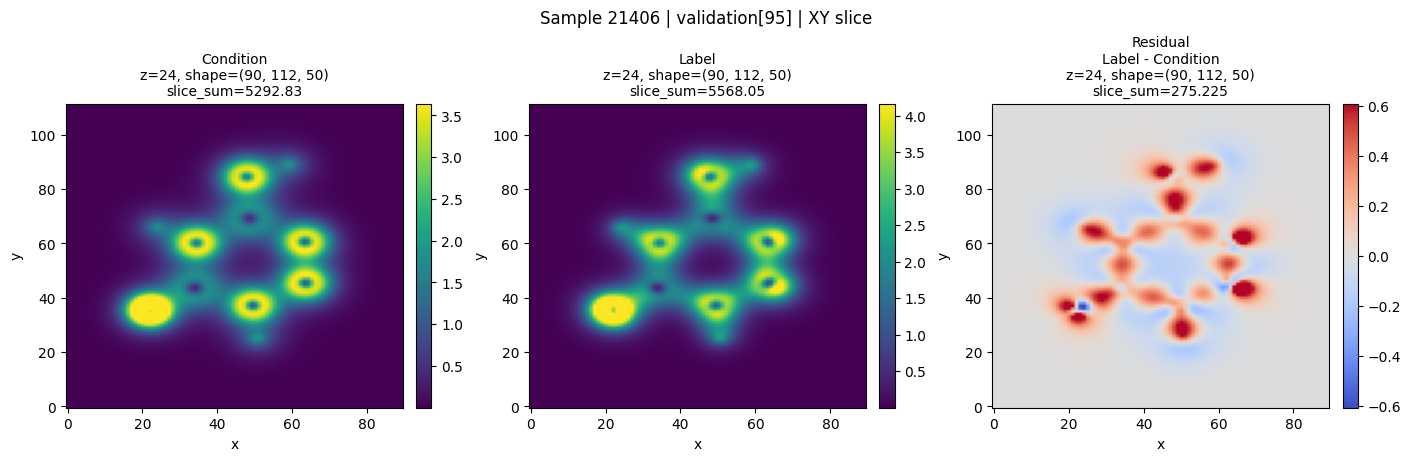

{'available_keys': ['condition',
  'device',
  'figure',
  'label',
  'output_path',
  'plane',
  'residual',
  'sample_id',
  'sample_idx',
  'slice_indices',
  'slice_sums',
  'split'],
 'sample_id': '21406',
 'sample_idx': 95,
 'split': 'validation',
 'device': 'cuda',
 'plane': 'xy',
 'slice_indices': {'condition': 24, 'label': 24, 'residual': 24},
 'slice_sums': {'condition': 5292.825152761252,
  'label': 5568.049995409725,
  'residual': 275.2248426489062},
 'condition_shape': (1, 1, 90, 112, 50),
 'label_shape': (1, 1, 90, 112, 50),
 'residual_shape': (1, 1, 90, 112, 50)}

In [3]:
result = visualize_qm9_condition_label_residual_sample(
    root=ROOT,
    split_file=SPLIT_FILE,
    split=SPLIT,
    sample_idx=SAMPLE_IDX,
    seed=SEED,
    plane=PLANE,
    slice_index=SLICE_INDEX,
    slice_frac=SLICE_FRAC,
    output_path=OUTPUT_PATH,
    device=DEVICE,
    show=True,
)

{
    'available_keys': sorted(result.keys()),
    'sample_id': result['sample_id'],
    'sample_idx': result['sample_idx'],
    'split': result['split'],
    'device': result['device'],
    'plane': result['plane'],
    'slice_indices': result['slice_indices'],
    'slice_sums': result['slice_sums'],
    'condition_shape': tuple(result['condition'].shape),
    'label_shape': tuple(result['label'].shape),
    'residual_shape': tuple(result['residual'].shape),
}


In [ ]:
{
    key: tuple(result[key].shape)
    for key in (
        'condition',
        'label',
        'residual',
    )
}
